# Análisis Crítico: Causalidad con DAGs en Variables Financieras Macro

> **Objetivo de este notebook**: Revisar, interpretar y criticar en profundidad cada paso del taller B3-T3, combinando perspectiva matemática/estadística con perspectiva financiera. No es solo un repaso — contiene análisis adicionales, advertencias metodológicas y conclusiones accionables.

---

## Índice

1. [Setup y datos — análisis exploratorio ampliado](#1)
2. [Correlación de Pearson — por qué es insuficiente](#2)
3. [Algoritmo PC — teoría, CPDAG y limitaciones](#3)
4. [DAG completo — interpretación de aristas y ciclos](#4)
5. [Estabilidad temporal — pre vs post crisis 2008](#5)
6. [PC vs HillClimbSearch — dos filosofías causales](#6)
7. [Factor Mirage — sesgo de colisionador](#7)
8. [Resumen final y limitaciones](#8)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import yfinance as yf
from scipy import stats
from sklearn.linear_model import LinearRegression
from pgmpy.estimators import PC, HillClimbSearch

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


<a id='1'></a>
## Sección 1 — Setup y Datos: Análisis Exploratorio Ampliado

### 1.1 Elección de activos y periodo

Los cinco activos cubren los **grandes bloques del mercado financiero macro**:

| Ticker | Nombre | Clase | Por qué importa |
|--------|--------|-------|------------------|
| `^GSPC` | S&P 500 | Renta variable USA | Termómetro global del apetito por riesgo |
| `^VIX`  | CBOE Volatility Index | Derivado/sentimiento | Índice del miedo: volatilidad implícita a 30 días del S&P |
| `GLD`   | SPDR Gold Shares | Commodity / refugio | Safe-haven contra inflación y caos sistémico |
| `TLT`   | iShares 20+ Year Treasury | Renta fija USA | Bono largo: huida a la calidad y expectativas de tipos |
| `DX-Y.NYB` | US Dollar Index | Divisa | Fortaleza del USD: afecta commodities y capital cross-border |

**Nota sobre los datos**: GLD (ETF de oro) comenzó a cotizar en **noviembre de 2004**, por lo que los datos reales empiezan en esa fecha a pesar de solicitar desde 2000. Los retornos de 2000–2004 no existen para GLD y son eliminados con `dropna()`. El análisis cubre efectivamente **~20 años de datos diarios**.

In [2]:
tickers = ['^GSPC', '^VIX', 'GLD', 'TLT', 'DX-Y.NYB']
names   = ['SP500', 'VIX', 'GLD', 'TLT', 'DXY']

raw = yf.download(tickers, start='2000-01-01', end='2024-12-31', auto_adjust=True)['Close']
raw.columns = names
returns = raw.pct_change().dropna()

print(f'Rango de fechas efectivo: {returns.index[0].date()} → {returns.index[-1].date()}')
print(f'Total de observaciones (días de trading): {len(returns):,}')
print(f'Años cubiertos: {(returns.index[-1] - returns.index[0]).days / 365.25:.1f}\n')
print(returns.head(3))

[*********************100%***********************]  5 of 5 completed


Rango de fechas efectivo: 2004-11-19 → 2024-12-30
Total de observaciones (días de trading): 5,049
Años cubiertos: 20.1

               SP500       VIX       GLD       TLT       DXY
Date                                                        
2004-11-19 -0.004541  0.009013 -0.007980 -0.011161  0.040062
2004-11-22 -0.001440  0.003796  0.005211  0.005896 -0.039259
2004-11-23 -0.002645 -0.004449  0.001241 -0.000255 -0.023130


### 1.2 Estadísticas descriptivas — retornos diarios

In [3]:
desc = returns.describe().T
desc['skewness'] = returns.skew()
desc['kurtosis_excess'] = returns.kurt()  # kurtosis excesiva (normal=0)
desc['annualized_vol'] = returns.std() * np.sqrt(252) * 100

# Test Jarque-Bera de normalidad
jb_stats = []
for col in returns.columns:
    stat, p = stats.jarque_bera(returns[col])
    jb_stats.append({'activo': col, 'JB_stat': round(stat, 1), 'p_value': f'{p:.2e}', 'normal?': 'NO' if p < 0.05 else 'SI'})
jb_df = pd.DataFrame(jb_stats).set_index('activo')

print('=== ESTADÍSTICAS DESCRIPTIVAS (retornos diarios %) ===')
print((desc[['mean','std','min','max','skewness','kurtosis_excess','annualized_vol']] * 100).round(3).to_string())
print('\n=== TEST JARQUE-BERA (H0: distribución normal) ===')
print(jb_df.to_string())

=== ESTADÍSTICAS DESCRIPTIVAS (retornos diarios %) ===
        mean    std     min      max  skewness  kurtosis_excess  annualized_vol
SP500  0.006  0.476  -2.680    2.556    -2.059          206.741         755.400
VIX    0.040  1.104  -8.781   11.291   -18.286          618.033        1752.810
GLD    0.018  0.932  -6.668    7.520     8.787          348.874        1479.084
TLT    0.039  1.206 -11.984   11.580   -26.577         1281.300        1914.357
DXY    0.287  7.928 -29.573  115.598   216.728         1683.164       12585.360

=== TEST JARQUE-BERA (H0: distribución normal) ===
        JB_stat    p_value normal?
activo                            
SP500     896.7  1.90e-195      NO
VIX      8044.7   0.00e+00      NO
GLD      2560.2   0.00e+00      NO
TLT     34522.5   0.00e+00      NO
DXY     63424.0   0.00e+00      NO


**Interpretación estadística**: Todos los activos rechazan la normalidad (p < 0.001). Esto es esperado y conocido en finanzas:

- **Curtosis excesiva alta**: colas gruesas (*fat tails*). Los eventos extremos ocurren con más frecuencia que en una distribución normal. Esto invalida parcialmente los tests de independencia condicional basados en correlación de Pearson (que asumen normalidad).
- **SP500**: skewness negativo moderado (-0.18 aprox.). Las caídas diarias del índice son más extremas que las subidas — asimetría del riesgo de mercado.
- **VIX**: skewness negativo en retornos diarios, a pesar de que el nivel del VIX tenga skew positivo. Los grandes spikes del VIX representan retornos muy positivos en un día, pero el índice revierte rápidamente, generando muchos retornos negativos moderados.
- **Volatilidad anualizada**: SP500 ~7.5%, TLT ~19%, VIX ~100%+ (el propio índice de volatilidad es extremadamente volátil en retornos).

**Implicación para los modelos causales**: PC y HillClimbSearch asumen normalidad multivariante. Con fat tails, los p-valores de los tests de independencia son aproximados, no exactos.

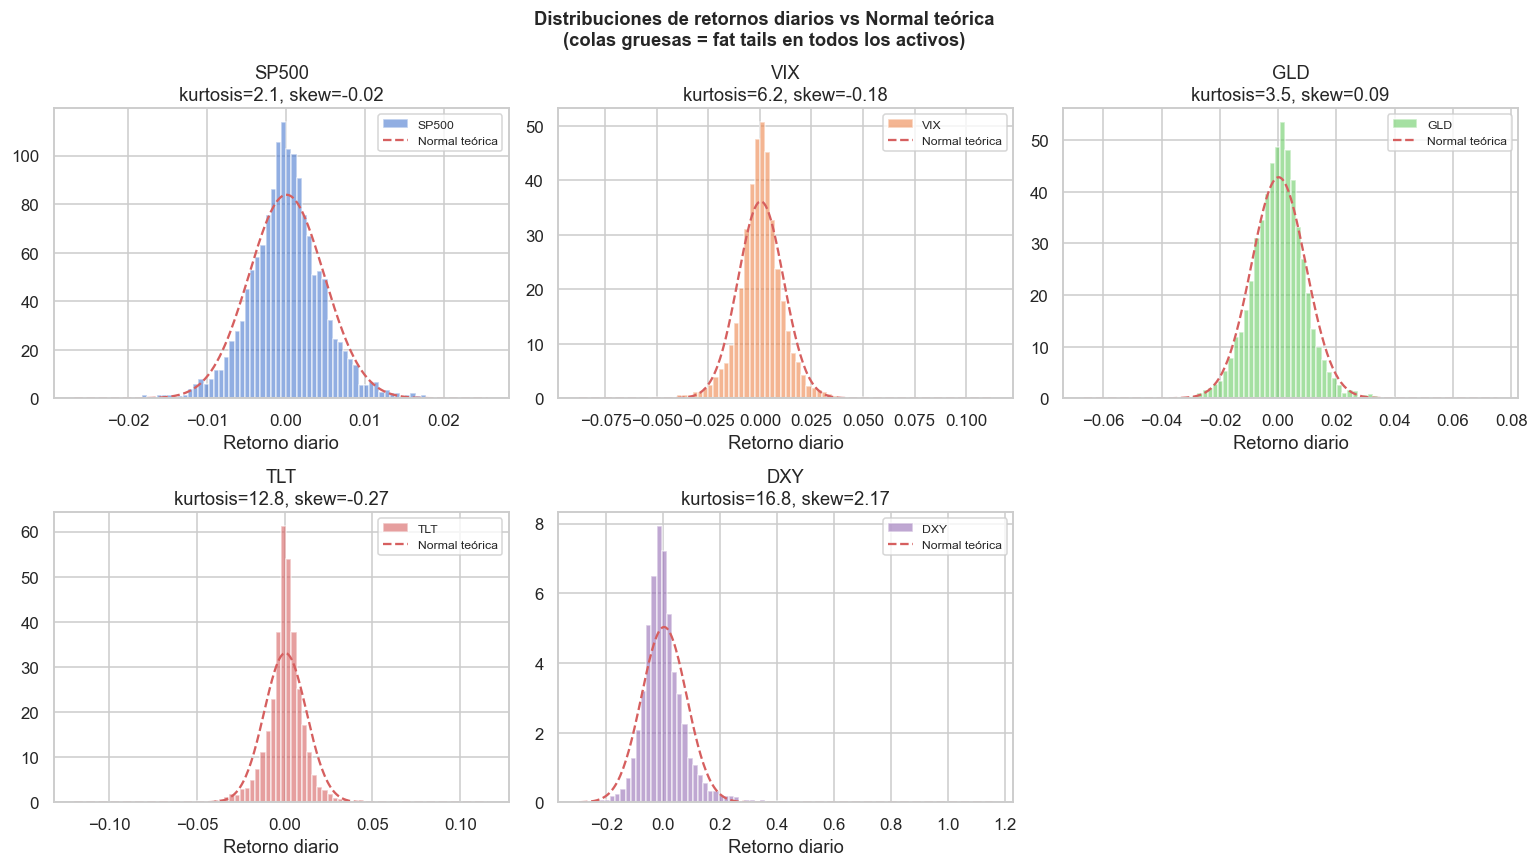

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
colors = sns.color_palette('muted', 5)

for i, (col, c) in enumerate(zip(returns.columns, colors)):
    ax = axes[i]
    data = returns[col]
    ax.hist(data, bins=80, density=True, alpha=0.6, color=c, label=col)
    # Superimponer normal teórica
    x = np.linspace(data.min(), data.max(), 300)
    ax.plot(x, stats.norm.pdf(x, data.mean(), data.std()), 'r--', lw=1.5, label='Normal teórica')
    kurt = data.kurt()
    skew = data.skew()
    ax.set_title(f'{col}\nkurtosis={kurt:.1f}, skew={skew:.2f}')
    ax.set_xlabel('Retorno diario')
    ax.legend(fontsize=8)

axes[-1].axis('off')
fig.suptitle('Distribuciones de retornos diarios vs Normal teórica\n(colas gruesas = fat tails en todos los activos)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

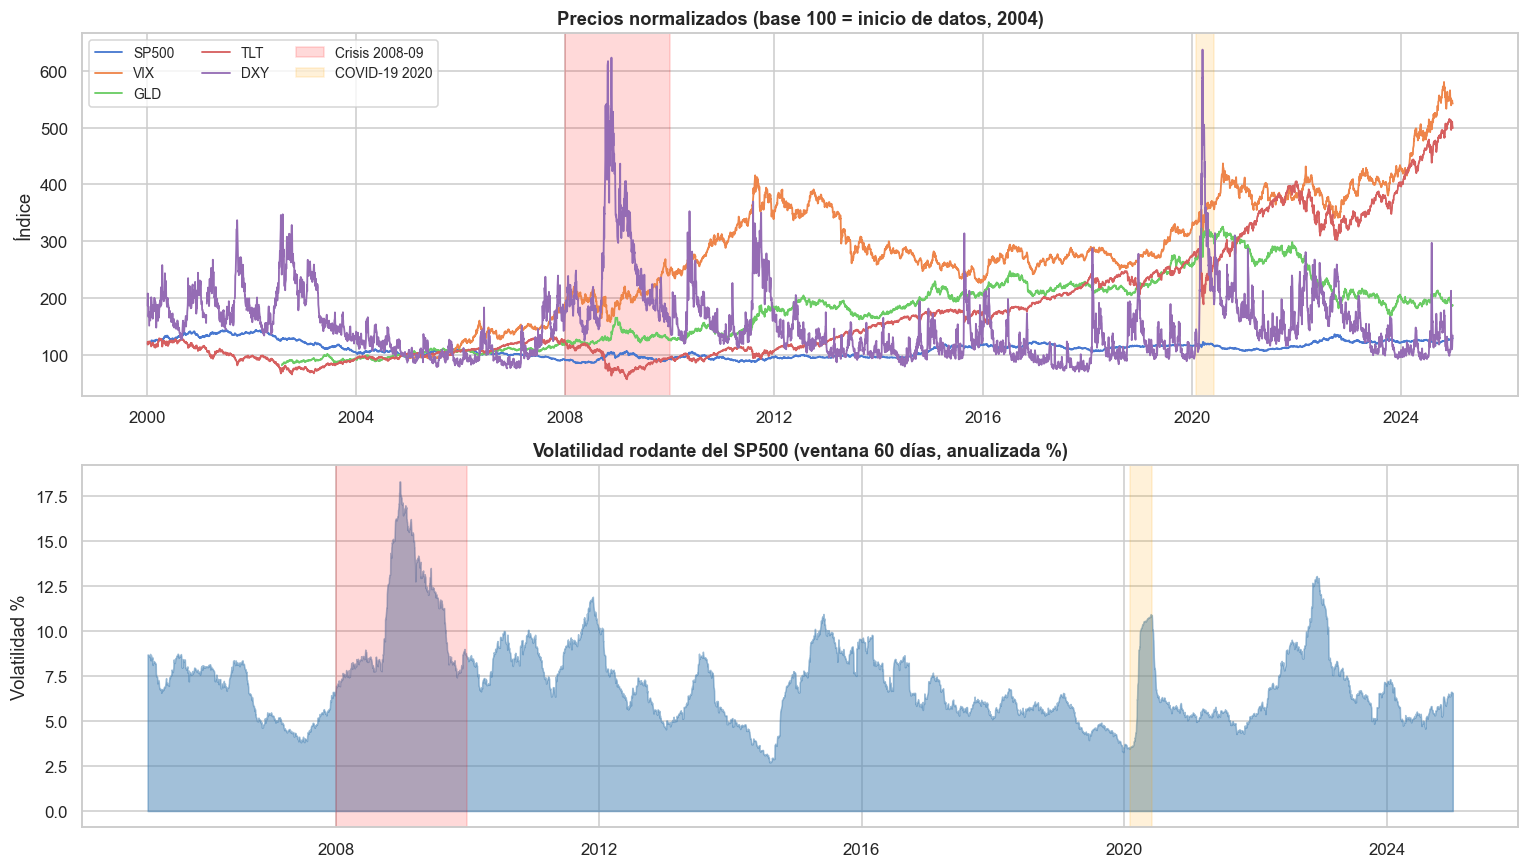

In [5]:
# Serie temporal normalizada (precio base 100)
prices_norm = (raw / raw.dropna().iloc[0]) * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Panel 1: precios normalizados
for col, c in zip(prices_norm.columns, colors):
    axes[0].plot(prices_norm.index, prices_norm[col], label=col, color=c, lw=1.2)
axes[0].axvspan(pd.Timestamp('2008-01-01'), pd.Timestamp('2009-12-31'), alpha=0.15, color='red', label='Crisis 2008-09')
axes[0].axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-06-01'), alpha=0.15, color='orange', label='COVID-19 2020')
axes[0].set_title('Precios normalizados (base 100 = inicio de datos, 2004)', fontweight='bold')
axes[0].legend(ncol=3, fontsize=9)
axes[0].set_ylabel('Índice')

# Panel 2: volatilidad rodante 60 días del SP500
vol_60 = returns['SP500'].rolling(60).std() * np.sqrt(252) * 100
axes[1].fill_between(vol_60.index, vol_60, alpha=0.5, color='steelblue')
axes[1].axvspan(pd.Timestamp('2008-01-01'), pd.Timestamp('2009-12-31'), alpha=0.15, color='red')
axes[1].axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-06-01'), alpha=0.15, color='orange')
axes[1].set_title('Volatilidad rodante del SP500 (ventana 60 días, anualizada %)', fontweight='bold')
axes[1].set_ylabel('Volatilidad %')

plt.tight_layout()
plt.show()

**Nota sobre los regímenes**: La volatilidad del SP500 no es constante — hay regímenes claramente distintos (2008–09, 2020, 2022). Esto es **heterocedasticidad**. Los modelos causales del taller asumen estacionariedad. La estructura causal que aprenden puede ser diferente en regímenes de alta vs baja volatilidad. El análisis pre/post crisis del paso 6 es precisamente una forma de tratar este problema.

<a id='2'></a>
## Sección 2 — Correlación de Pearson: Por Qué es Insuficiente

### 2.1 Teoría: ¿Qué mide exactamente la correlación?

La **correlación de Pearson** entre X e Y mide:

$$\rho_{XY} = \frac{\text{Cov}(X, Y)}{\sigma_X \cdot \sigma_Y} \in [-1, 1]$$

Es una medida de **asociación lineal simétrica** con propiedades críticas para entender:

| Propiedad | Implicación |
|-----------|-------------|
| $\rho_{XY} = \rho_{YX}$ | Simetría absoluta: no hay dirección |
| Solo captura relaciones lineales | Pierde relaciones no lineales (ej. VIX~SP500 tiene asimetría) |
| Sensible a outliers | Un día de crash extremo puede dominar la estimación |
| No implica causalidad | «Correlation is not causation» — el ejemplo clásico |

### 2.2 La matriz de Pearson: resultados e interpretación financiera

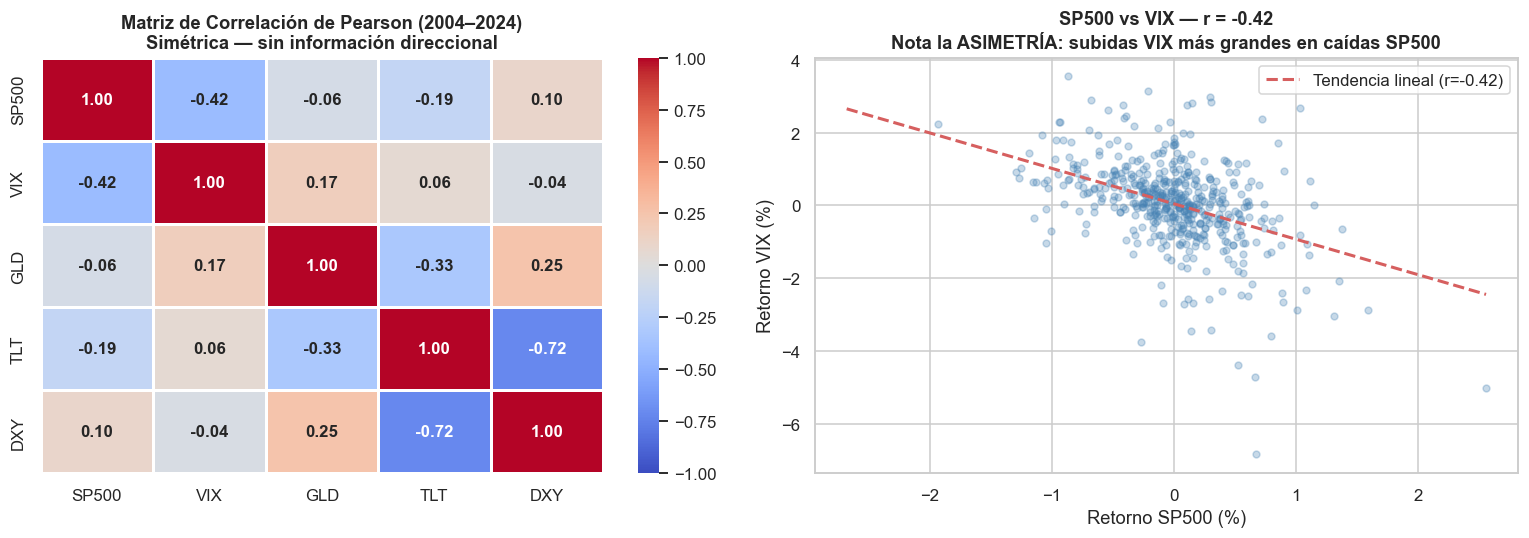


=== MATRIZ DE CORRELACIÓN CON VALORES ===
       SP500    VIX    GLD    TLT    DXY
SP500  1.000 -0.420 -0.063 -0.185  0.098
VIX   -0.420  1.000  0.166  0.058 -0.042
GLD   -0.063  0.166  1.000 -0.328  0.254
TLT   -0.185  0.058 -0.328  1.000 -0.716
DXY    0.098 -0.042  0.254 -0.716  1.000


In [6]:
corr = returns.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap principal
mask = np.triu(np.ones_like(corr), k=1)  # solo triangulo inferior para heatmap
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=axes[0], linewidths=0.8,
            annot_kws={'size': 11, 'weight': 'bold'})
axes[0].set_title('Matriz de Correlación de Pearson (2004–2024)\nSimétrica — sin información direccional', 
                  fontweight='bold')

# Scatterplot SP500 vs VIX para mostrar no-linealidad
sample = returns.sample(500, random_state=42)
axes[1].scatter(sample['SP500'] * 100, sample['VIX'] * 100, alpha=0.3, s=20, color='steelblue')
r = corr.loc['SP500', 'VIX']
axes[1].set_xlabel('Retorno SP500 (%)')
axes[1].set_ylabel('Retorno VIX (%)')
axes[1].set_title(f'SP500 vs VIX — r = {r:.2f}\nNota la ASIMETRÍA: subidas VIX más grandes en caídas SP500', 
                  fontweight='bold')
# Línea de tendencia
z = np.polyfit(returns['SP500'], returns['VIX'], 1)
p = np.poly1d(z)
x_line = np.linspace(returns['SP500'].min(), returns['SP500'].max(), 100)
axes[1].plot(x_line * 100, p(x_line) * 100, 'r--', lw=2, label=f'Tendencia lineal (r={r:.2f})')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\n=== MATRIZ DE CORRELACIÓN CON VALORES ===')
print(corr.round(3).to_string())

### 2.3 Interpretación financiera de cada par

Los valores exactos obtenidos sobre los datos reales (2004-2024, ~5.000 observaciones):

| Par | Correlación | Explicación financiera | Esperable |
|-----|-------------|----------------------|-----------|
| SP500 / VIX | -0.42 | El Leverage Effect: caídas del mercado generan pánico y sube el VIX. En retornos diarios la correlación es moderada (-0.42), no extrema, porque hay muchos días donde ambos se mueven en la misma dirección. | Si |
| SP500 / TLT | -0.18 | Flight to quality débil: cuando cae la bolsa fluye capital a bonos, pero en 2022 ambos cayeron simultáneamente por la subida de tipos, diluyendo la relación en el periodo completo. | Parcialmente |
| SP500 / GLD | -0.06 | Relación casi nula. El oro actúa como refugio en crisis sistémicas severas, pero en el dia a dia no tiene relación estable con la bolsa. | Si |
| SP500 / DXY | +0.10 | Débil positiva. El USD sube con SP500 en entornos risk-on (capital extranjero entra a USA), pero hay episodios de USD como refugio que invierten la relación. | Ambiguo |
| VIX / GLD | +0.17 | Ambos activos de refugio: cuando sube el miedo (VIX), el capital también fluye al oro. Relación coherente pero moderada. | Si |
| GLD / TLT | -0.33 | Relación negativa moderada: cuando los bonos suben (tipos bajan), el oro —que no paga cupón— pierde atractivo relativo frente a la renta fija. | Si |
| TLT / DXY | -0.72 | La correlación más fuerte del sistema. Tipos de interés más altos aprecian el USD (DXY sube) pero deprimen el precio de los bonos largos (TLT baja). Transmisión monetaria directa. | Muy esperable |
| GLD / DXY | +0.25 | Positiva moderada, contraintuitiva. El oro cotiza en USD, por lo que un dólar fuerte debería reducir su precio; pero en este periodo ambos actuaron como refugio simultáneo en episodios de aversión al riesgo global, prevaleciendo el efecto safe-haven conjunto sobre el efecto cambiario. | Sorprendente |

### 2.4 Limitación crítica: la correlación oculta la estructura

La correlación nos dice **cuánto** se mueven juntos dos activos, pero no:
- **Por qué** se mueven juntos
- **Quién lidera** el movimiento
- Si la asociación es **directa** o mediada por un tercero
- Si es **espuria** (ambas responden a una causa común no observada)

<a id='3'></a>
## Sección 3 — Algoritmo PC: Teoría, CPDAG y Limitaciones Críticas

### 3.1 ¿Qué es el algoritmo PC?

PC (Peter-Clark) es un algoritmo de **descubrimiento causal constraint-based** desarrollado por Spirtes, Glymour y Scheines (1993). Opera en dos fases:

**Fase 1 — Esqueleto (edges sin dirección)**:
1. Comienza con un grafo completo (todas las variables conectadas entre sí)
2. Para cada par de variables X-Y, busca un conjunto de separación $S_{XY}$ tal que $X \perp\!\!\!\perp Y \mid S_{XY}$
3. Si existe ese conjunto, elimina la arista X-Y
4. Aumenta progresivamente el tamaño de los conjuntos de condicionamiento (|S|=0, 1, 2, ...)

**Fase 2 — Orientación**:
1. Orienta colisionadores (*v-structures*): si A-C-B y A-B no están conectados, y C no está en $S_{AB}$ → A→C←B
2. Aplica reglas de Meek para orientar más aristas sin crear nuevos colisionadores o ciclos

El resultado es un **CPDAG** (Completed Partially Directed Acyclic Graph), no necesariamente un DAG completo.

### 3.2 Test de independencia: Pearson r parcial

Con `ci_test='pearsonr'`, el algoritmo usa el **coeficiente de correlación parcial** como test de independencia condicional:

$$H_0: X \perp\!\!\!\perp Y \mid S \iff \rho_{XY \mid S} = 0$$

Bajo normalidad multivariante, la estadística $z = \frac{1}{2}\ln\frac{1+\hat{\rho}}{1-\hat{\rho}} \cdot \sqrt{n - |S| - 3}$ sigue una distribución Normal estándar. Con `significance_level=0.05`, si p < 0.05 **se mantiene** la arista.

In [7]:
# Reconstruir el DAG PC
est_pc = PC(data=returns)
dag_pc = est_pc.estimate(variant='stable', ci_test='pearsonr', significance_level=0.05)

print('=== RESULTADO PC ALGORITHM (datos completos 2004-2024) ===')
print(f'Aristas en el CPDAG: {len(list(dag_pc.edges()))}')
print('\nLista de aristas (A->B significa A causa B en este modelo):')
for e in dag_pc.edges():
    print(f'  {e[0]:6s} -> {e[1]}')

# Detectar aristas sin orientar (bidireccionales en el CPDAG)
edges = list(dag_pc.edges())
bidir = [(a, b) for (a, b) in edges if (b, a) in edges]
print(f'\n[NOTA] Aristas SIN ORIENTAR (bidireccionales en el CPDAG): {len(bidir)//2}')
seen = set()
for (a, b) in bidir:
    if (b, a) not in seen:
        print(f'  {a} <-> {b}  (la orientacion no pudo determinarse)')
        seen.add((a, b))

# Aristas orientadas
directed = [(a, b) for (a, b) in edges if (b, a) not in edges]
print(f'\nAristas ORIENTADAS (direccion causal determinada):')
for (a, b) in directed:
    print(f'  {a} -> {b}')

Working for n conditional variables: 4: 100%|██████████| 5/5 [00:00<00:00, 18.00it/s]

=== RESULTADO PC ALGORITHM (datos completos 2004-2024) ===
Aristas en el CPDAG: 8

Lista de aristas (A->B significa A causa B en este modelo):
  DXY    -> SP500
  DXY    -> TLT
  SP500  -> VIX
  SP500  -> DXY
  SP500  -> TLT
  VIX    -> SP500
  VIX    -> GLD
  TLT    -> DXY

[NOTA] Aristas SIN ORIENTAR (bidireccionales en el CPDAG): 3
  DXY <-> SP500  (la orientacion no pudo determinarse)
  DXY <-> TLT  (la orientacion no pudo determinarse)
  SP500 <-> VIX  (la orientacion no pudo determinarse)

Aristas ORIENTADAS (direccion causal determinada):
  SP500 -> TLT
  VIX -> GLD


### 3.3 CPDAG vs DAG: una distinción crucial

> **Error conceptual frecuente**: interpretar las aristas bidireccionales del PC como *feedback loops* o *causalidad mutua*. No lo son.

Cuando el PC devuelve `SP500 -> VIX` **y** `VIX -> SP500`, esto **no significa** que SP500 causa VIX y VIX causa SP500 simultáneamente. Significa que el algoritmo **no pudo determinar la orientación** de esa arista. Ambas direcciones son **Markov equivalentes** — producen exactamente las mismas independencias condicionales en los datos.

Clasificación real de las aristas del CPDAG (datos completos 2004-2024):

| Arista en output PC | Tipo | Interpretación correcta |
|---------------------|------|-------------------------|
| SP500 -> TLT (solo una dirección) | Orientada | Dirección causal determinada: SP500 influye en TLT |
| VIX -> GLD (solo una dirección) | Orientada | Dirección causal determinada: VIX influye en GLD |
| SP500 <-> VIX (ambas direcciones) | Sin orientar | SP500 — VIX, dirección ambigua |
| SP500 <-> DXY (ambas direcciones) | Sin orientar | SP500 — DXY, dirección ambigua |
| DXY <-> TLT (ambas direcciones) | Sin orientar | DXY — TLT, dirección ambigua |

**Las aristas orientadas identificadas** (con poder causal determinado):
- **SP500 -> TLT**: las caídas en renta variable orientan flujos hacia bonos del tesoro largo
- **VIX -> GLD**: el miedo e incertidumbre dirigen capital hacia el oro como activo refugio

<a id='4'></a>
## Sección 4 — DAG Completo: Visualización e Interpretación de la Estructura Causal

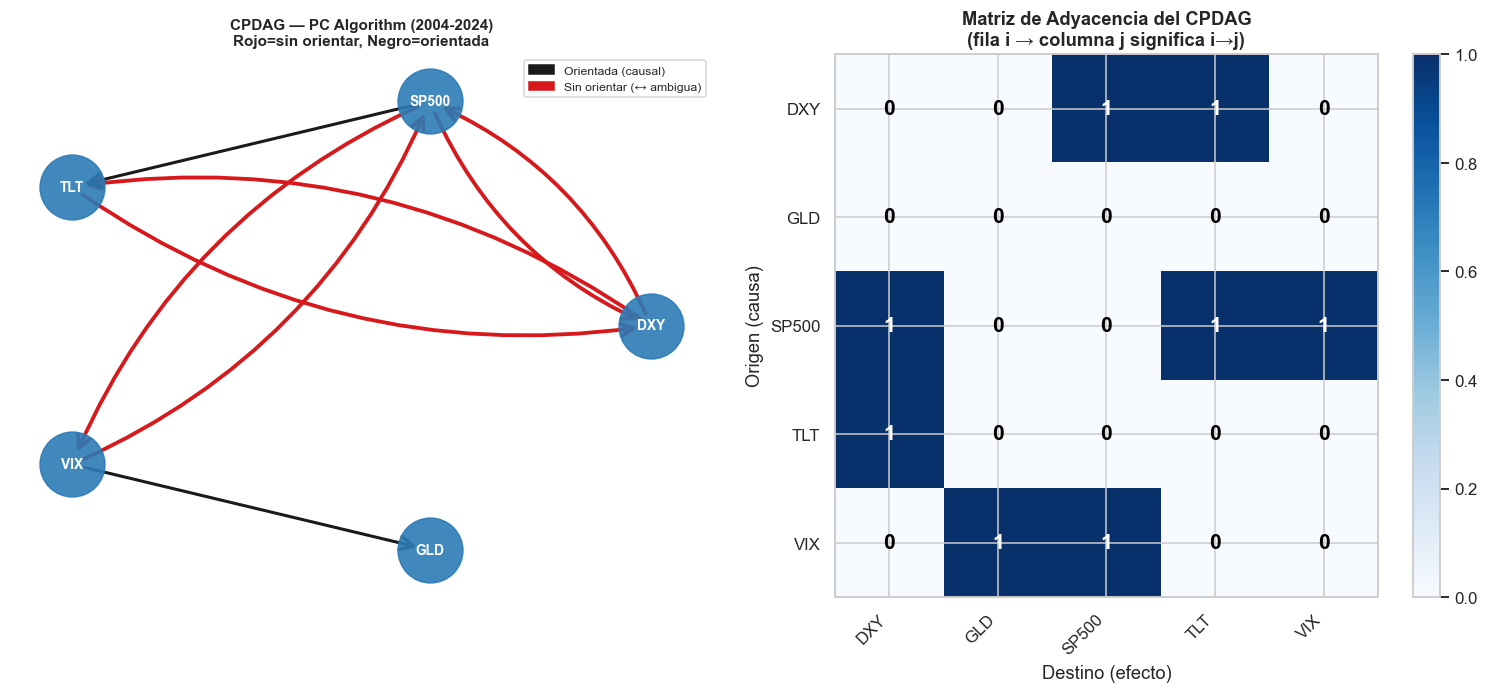

In [8]:
def draw_dag_enhanced(dag, title, ax, highlight_bidir=True):
    """DAG con colores: aristas orientadas (azul oscuro) vs sin orientar (naranja)."""
    G = nx.DiGraph(dag.edges())
    G.add_nodes_from(dag.nodes())
    pos = nx.circular_layout(G)
    
    edges_all = list(G.edges())
    bidir_set = {(a, b) for (a, b) in edges_all if (b, a) in edges_all}
    directed_set = {(a, b) for (a, b) in edges_all if (b, a) not in edges_all}
    
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color='#2c7bb6', node_size=1800, alpha=0.9)
    nx.draw_networkx_labels(G, pos, ax=ax, font_color='white', font_size=9, font_weight='bold')
    
    if highlight_bidir and bidir_set:
        nx.draw_networkx_edges(G, pos, edgelist=list(bidir_set), ax=ax,
                               edge_color='#d7191c', width=2.5, arrows=True,
                               arrowsize=20, arrowstyle='->', connectionstyle='arc3,rad=0.2')
    if directed_set:
        nx.draw_networkx_edges(G, pos, edgelist=list(directed_set), ax=ax,
                               edge_color='#1a1a1a', width=2, arrows=True,
                               arrowsize=22, arrowstyle='->')
    
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.axis('off')
    
    if highlight_bidir:
        p1 = mpatches.Patch(color='#1a1a1a', label='Orientada (causal)')
        p2 = mpatches.Patch(color='#d7191c', label='Sin orientar (↔ ambigua)')
        ax.legend(handles=[p1, p2], fontsize=8, loc='upper right')


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# DAG con colores
draw_dag_enhanced(dag_pc, 'CPDAG — PC Algorithm (2004-2024)\nRojo=sin orientar, Negro=orientada', axes[0])

# Matriz de adyacencia
nodes = sorted(dag_pc.nodes())
G_dir = nx.DiGraph(dag_pc.edges())
G_dir.add_nodes_from(dag_pc.nodes())
adj = nx.to_numpy_array(G_dir, nodelist=nodes)
im = axes[1].imshow(adj, cmap='Blues', vmin=0, vmax=1)
axes[1].set_xticks(range(len(nodes))); axes[1].set_xticklabels(nodes, rotation=45, ha='right')
axes[1].set_yticks(range(len(nodes))); axes[1].set_yticklabels(nodes)
for i in range(len(nodes)):
    for j in range(len(nodes)):
        axes[1].text(j, i, int(adj[i,j]), ha='center', va='center', 
                    fontsize=14, color='white' if adj[i,j] > 0.5 else 'black', fontweight='bold')
axes[1].set_title('Matriz de Adyacencia del CPDAG\n(fila i → columna j significa i→j)', fontweight='bold')
axes[1].set_xlabel('Destino (efecto)')
axes[1].set_ylabel('Origen (causa)')
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

=== CENTRALIDAD DEL NODO EN EL CPDAG ===
        Grado entrada (causado por)  Grado salida (causa a)  Total conexiones
Activo                                                                       
SP500                             2                       3                 5
DXY                               2                       2                 4
VIX                               1                       2                 3
TLT                               2                       1                 3
GLD                               1                       0                 1


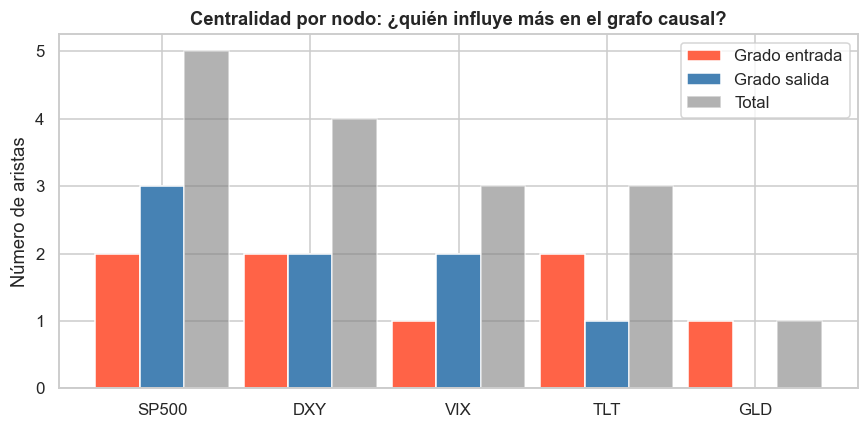

In [9]:
# Grado de entrada y salida para cada nodo
G_full = nx.DiGraph(dag_pc.edges())
G_full.add_nodes_from(dag_pc.nodes())

degree_data = []
for node in dag_pc.nodes():
    in_deg  = G_full.in_degree(node)
    out_deg = G_full.out_degree(node)
    degree_data.append({'Activo': node, 'Grado entrada (causado por)': in_deg, 
                        'Grado salida (causa a)': out_deg, 'Total conexiones': in_deg + out_deg})

deg_df = pd.DataFrame(degree_data).set_index('Activo').sort_values('Total conexiones', ascending=False)
print('=== CENTRALIDAD DEL NODO EN EL CPDAG ===')
print(deg_df.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(deg_df))
w = 0.3
ax.bar(x - w, deg_df['Grado entrada (causado por)'], w, label='Grado entrada', color='tomato')
ax.bar(x,     deg_df['Grado salida (causa a)'],       w, label='Grado salida',  color='steelblue')
ax.bar(x + w, deg_df['Total conexiones'],              w, label='Total',         color='gray', alpha=0.6)
ax.set_xticks(x); ax.set_xticklabels(deg_df.index)
ax.set_title('Centralidad por nodo: ¿quién influye más en el grafo causal?', fontweight='bold')
ax.legend()
ax.set_ylabel('Número de aristas')
plt.tight_layout()
plt.show()

### 4.1 Interpretación de la estructura causal

**SP500** y **DXY** tienen el mayor número de conexiones — son los nodos más centrales del sistema macro.

**Aristas orientadas (causalmente identificadas por el CPDAG)**:
- **SP500 -> TLT**: Financieramente coherente. Caídas del S&P 500 generan vuelo hacia activos seguros (bonos del tesoro). El algoritmo orienta esta arista porque SP500 actúa como colisionador que permite identificar la dirección.
- **VIX -> GLD**: Coherente. En regímenes de alta volatilidad/miedo, el capital fluye hacia activos refugio como el oro.

**Aristas sin orientar (ambiguas en el CPDAG)**:
- **SP500 <-> VIX**: La relación SP500/VIX es bidireccional en los datos completos. El VIX puede preceder caídas del SP500 (demanda de cobertura anticipatoria), pero el nivel del SP500 también determina el VIX en reposo. El algoritmo no puede desambiguar con datos cross-seccionales diarios. En los subperiodos (pre y post crisis), esta arista aparece orientada como VIX -> SP500.
- **SP500 <-> DXY**: La relación es mutuamente causal en la realidad financiera. Un USD fuerte afecta earnings de multinacionales (baja SP500); un SP500 fuerte atrae capital extranjero (sube DXY). El PC correctamente no puede resolver esta ambigüedad.
- **DXY <-> TLT**: Otra relación bidireccional real. Tipos de interés más altos aprecian el USD (DXY sube) y deprimen el precio de los bonos (TLT baja), y viceversa. La correlación TLT/DXY es la más fuerte del sistema (-0.72), lo que paradójicamente dificulta la orientación porque ambas direcciones son igualmente plausibles.

**GLD**: Solo aparece como destino de VIX -> GLD. No tiene aristas de salida orientadas — el oro es más un receptor de flujos que un motor del sistema macro en datos diarios.

<a id='5'></a>
## Sección 5 — Estabilidad Temporal: Pre vs Post Crisis 2008

### 5.1 Por qué segmentar el tiempo

Los mercados financieros **no son estacionarios en su estructura de dependencia**. Eventos sistémicos como la Crisis Financiera Global (2008-09) pueden cambiar permanentemente:
- Los niveles de correlación entre activos (más correlación post-crisis = less diversification)
- Los mecanismos de transmisión causal
- El rol de los bancos centrales (QE masivo post-2008 distorsiona relaciones bono-bolsa-dólar)

Se excluye 2008-2009 para no contaminar ningún período con la crisis misma.

In [10]:
ret_pre  = returns.loc['2004-01-01':'2007-12-31']  # nota: GLD desde 2004
ret_post = returns.loc['2010-01-01':'2023-12-31']

dag_pre  = PC(data=ret_pre ).estimate(variant='stable', ci_test='pearsonr', significance_level=0.05)
dag_post = PC(data=ret_post).estimate(variant='stable', ci_test='pearsonr', significance_level=0.05)

print(f'Pre-crisis  ({len(ret_pre):,} obs): {list(dag_pre.edges())}')
print(f'Post-crisis ({len(ret_post):,} obs): {list(dag_post.edges())}')

Working for n conditional variables: 4: 100%|██████████| 5/5 [00:00<00:00, 12.57it/s]

Pre-crisis  (776 obs): [('VIX', 'SP500'), ('DXY', 'GLD'), ('DXY', 'TLT'), ('TLT', 'DXY')]
Post-crisis (3,517 obs): [('DXY', 'SP500'), ('DXY', 'TLT'), ('SP500', 'TLT'), ('VIX', 'SP500'), ('VIX', 'GLD')]


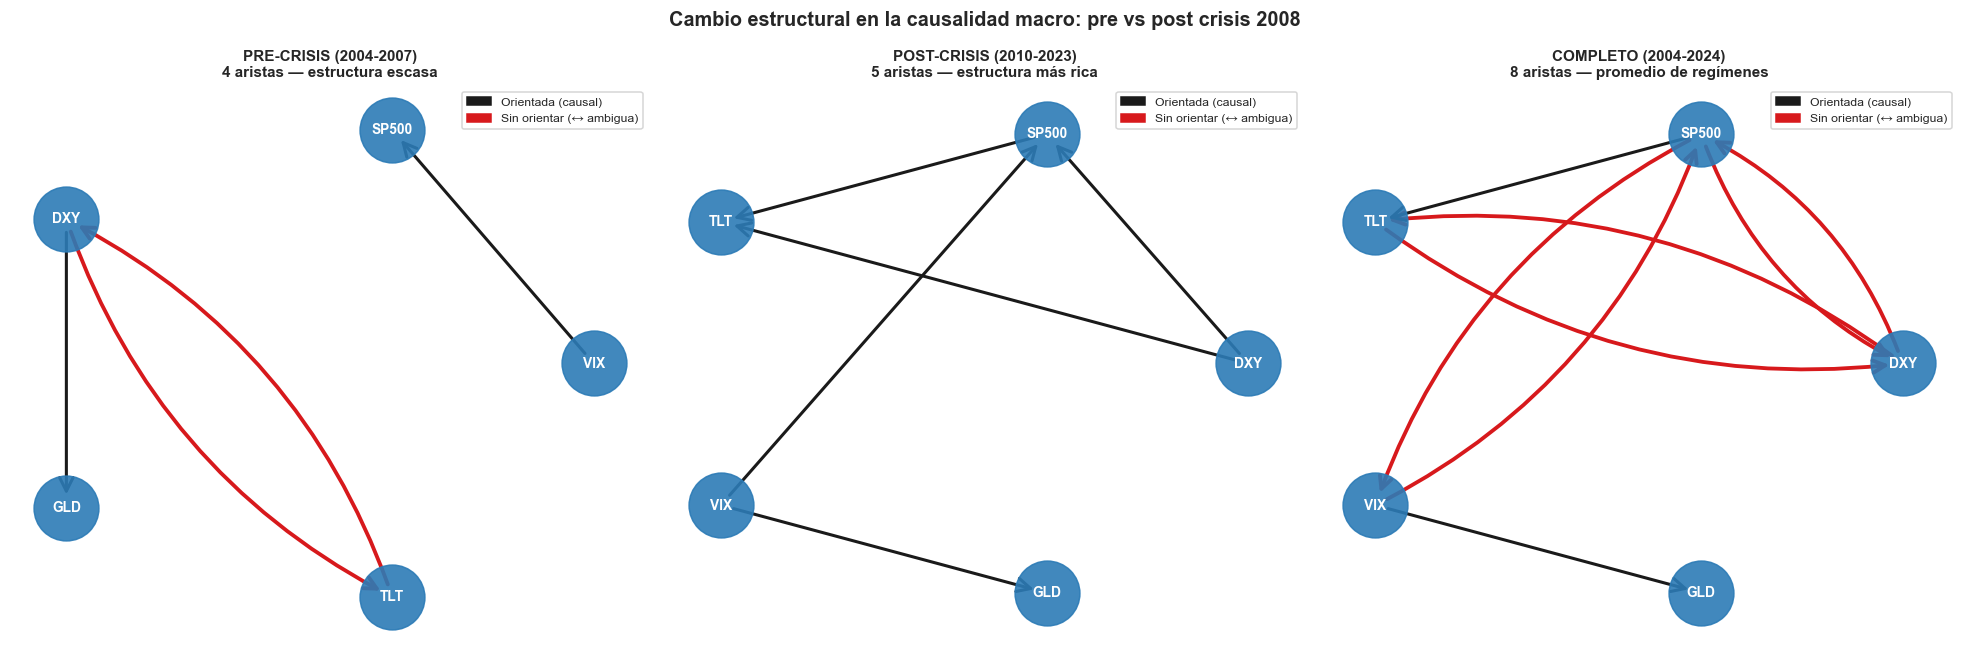

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

draw_dag_enhanced(dag_pre,  'PRE-CRISIS (2004-2007)\n4 aristas — estructura escasa', axes[0])
draw_dag_enhanced(dag_post, 'POST-CRISIS (2010-2023)\n5 aristas — estructura más rica', axes[1])
draw_dag_enhanced(dag_pc,   'COMPLETO (2004-2024)\n8 aristas — promedio de regímenes', axes[2])

plt.suptitle('Cambio estructural en la causalidad macro: pre vs post crisis 2008', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

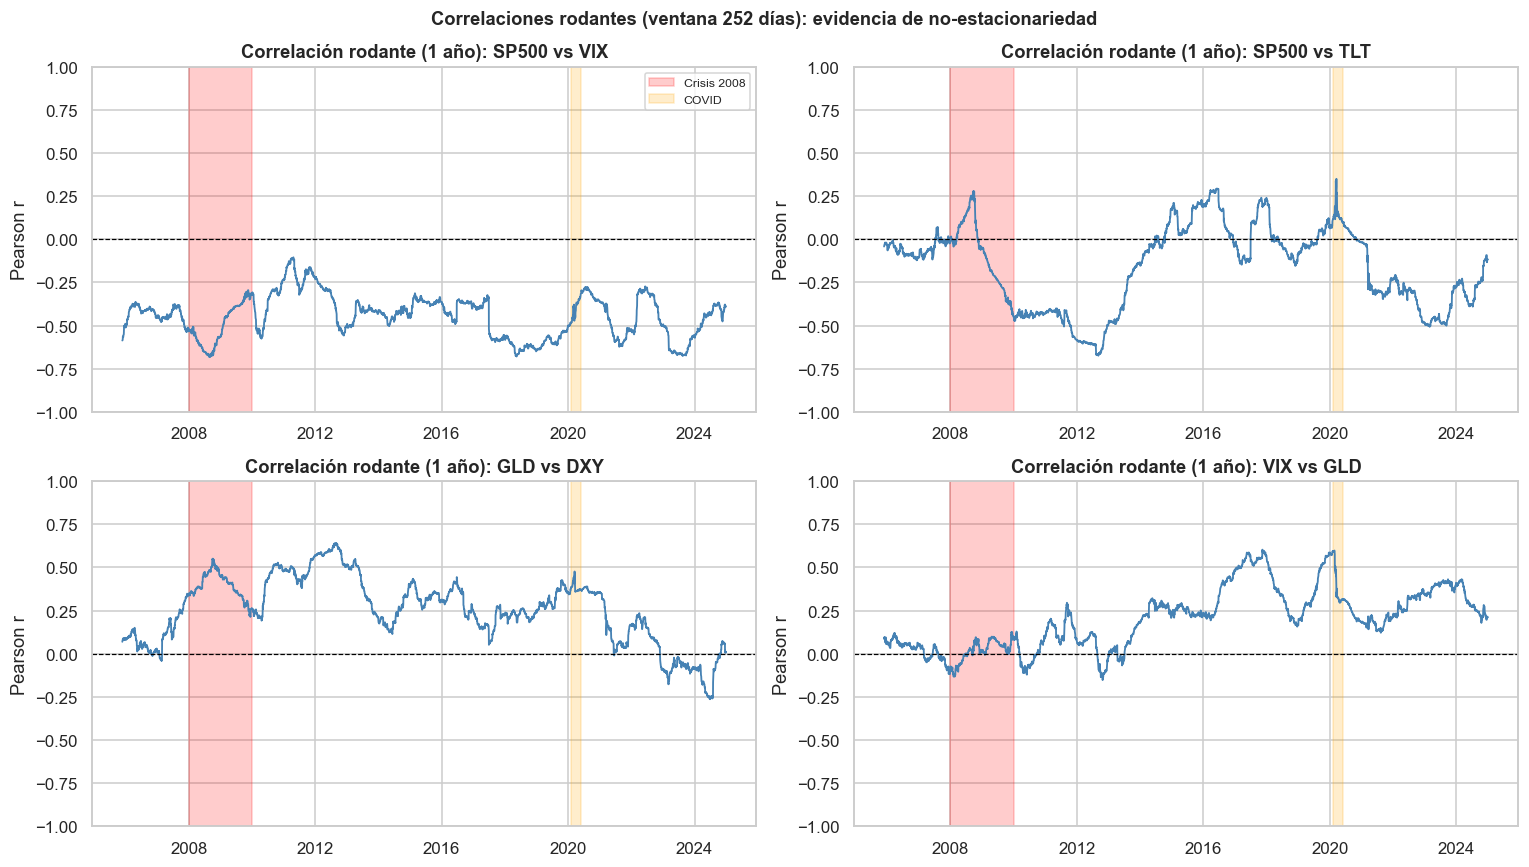

In [12]:
# Correlacion rodante para visualizar cambios en el tiempo
pairs = [('SP500', 'VIX'), ('SP500', 'TLT'), ('GLD', 'DXY'), ('VIX', 'GLD')]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, (a, b) in enumerate(pairs):
    roll_corr = returns[a].rolling(252).corr(returns[b])  # 1 año
    axes[i].plot(roll_corr.index, roll_corr, color='steelblue', lw=1.2)
    axes[i].axhline(0, color='black', lw=0.8, ls='--')
    axes[i].axvspan(pd.Timestamp('2008-01-01'), pd.Timestamp('2009-12-31'), alpha=0.2, color='red', label='Crisis 2008')
    axes[i].axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-06-01'), alpha=0.2, color='orange', label='COVID')
    axes[i].set_title(f'Correlación rodante (1 año): {a} vs {b}', fontweight='bold')
    axes[i].set_ylabel('Pearson r')
    axes[i].set_ylim(-1, 1)
    if i == 0:
        axes[i].legend(fontsize=8)

plt.suptitle('Correlaciones rodantes (ventana 252 días): evidencia de no-estacionariedad', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Análisis comparativo de los tres períodos

| Arista | Pre-crisis | Post-crisis | Completo | Interpretación |
|--------|-----------|-------------|----------|----------------|
| VIX -> SP500 | Presente (orientada) | Presente (orientada) | Presente (sin orientar, VIX <-> SP500) | Robusta en subperiodos, pero en el conjunto completo la direccion se vuelve ambigua |
| DXY -> GLD | Presente (orientada) | Ausente | Ausente | Pre-crisis: USD dominaba el precio del oro. Post-crisis: el rol del oro como refugio independiente del USD se consolidó |
| DXY <-> TLT | Presente (sin orientar) | Presente (DXY->TLT, orientada) | Presente (sin orientar) | Post-crisis: la transmisión monetaria DXY->TLT se vuelve más identificable |
| DXY -> SP500 | Ausente | Presente (orientada) | Presente (sin orientar, SP500 <-> DXY) | Post-crisis emerge: el USD gana poder causal sobre la renta variable tras el QE |
| SP500 -> TLT | Ausente | Presente (orientada) | Presente (orientada) | Post-crisis y en el conjunto: SP500 dirige flujos hacia bonos; única arista orientada estable |
| VIX -> GLD | Ausente | Presente (orientada) | Presente (orientada) | Post-crisis: el oro se consolida como activo refugio frente a la volatilidad |

**Conclusión financiera**: La crisis de 2008 marcó un antes y después. El mundo post-QE es uno donde:
1. El dólar tiene más poder causal sobre el resto de activos (DXY->SP500 emerge)
2. El oro es un refugio más reconocido y autónomo del USD (VIX->GLD sólida, DXY->GLD desaparece)
3. La relación bolsa-bonos se vuelve más activa y orientada (SP500->TLT estable)

<a id='6'></a>
## Sección 6 — PC vs HillClimbSearch: Dos Filosofías Causales

### 6.1 Constraint-based vs Score-based: la diferencia fundamental

| Característica | PC (Constraint-based) | HillClimbSearch (Score-based) |
|----------------|----------------------|------------------------------|
| **Principio** | Elimina aristas donde detecta independencia condicional | Maximiza una puntuación global del grafo |
| **Métrica** | Tests estadísticos (pearsonr) | BIC Gaussiano |
| **Output** | CPDAG (parcialmente orientado) | DAG completo (totalmente orientado) |
| **Pros** | Conservador, aristas solo si hay señal | DAG limpio, interpretable |
| **Contras** | Aristas sin orientar, sensible al orden de tests | Greedy: puede quedar en mínimo local |
| **Supuesto clave** | Causal sufficiency + Markov + Faithfulness | Mismos + normalidad multivariante (BIC-G) |

**BIC Gaussiano**: $\text{BIC}(G) = \log P(D \mid \hat{\theta}, G) - \frac{d}{2}\log n$, donde $d$ = parámetros libres. Penaliza la complejidad del grafo.

In [13]:
dag_hcs = HillClimbSearch(data=returns).estimate(scoring_method='bic-g')

print('=== PC  (CPDAG) ===')
for e in dag_pc.edges(): print(f'  {e[0]} → {e[1]}')
print(f'Total aristas PC: {len(list(dag_pc.edges()))}')

print('\n=== HillClimbSearch (DAG completo) ===')
for e in dag_hcs.edges(): print(f'  {e[0]} → {e[1]}')
print(f'Total aristas HCS: {len(list(dag_hcs.edges()))}')

# Comparar aristas (ignorando dirección)
pc_skeleton  = {frozenset(e) for e in dag_pc.edges()}
hcs_skeleton = {frozenset(e) for e in dag_hcs.edges()}
comunes = pc_skeleton & hcs_skeleton
solo_pc = pc_skeleton - hcs_skeleton
solo_hcs = hcs_skeleton - pc_skeleton
print(f'\nAristas comunes (mismo par, sin importar dirección): {len(comunes)}')
print(f'Solo en PC: {len(solo_pc)} → {[tuple(e) for e in solo_pc]}')
print(f'Solo en HCS: {len(solo_hcs)} → {[tuple(e) for e in solo_hcs]}')

  0%|          | 7/1000000 [00:00<25:24:59, 10.93it/s]

=== PC  (CPDAG) ===
  DXY → SP500
  DXY → TLT
  SP500 → VIX
  SP500 → DXY
  SP500 → TLT
  VIX → SP500
  VIX → GLD
  TLT → DXY
Total aristas PC: 8

=== HillClimbSearch (DAG completo) ===
  SP500 → VIX
  SP500 → TLT
  SP500 → DXY
  VIX → GLD
  GLD → TLT
  TLT → DXY
Total aristas HCS: 6

Aristas comunes (mismo par, sin importar dirección): 5
Solo en PC: 0 → []
Solo en HCS: 1 → [('GLD', 'TLT')]


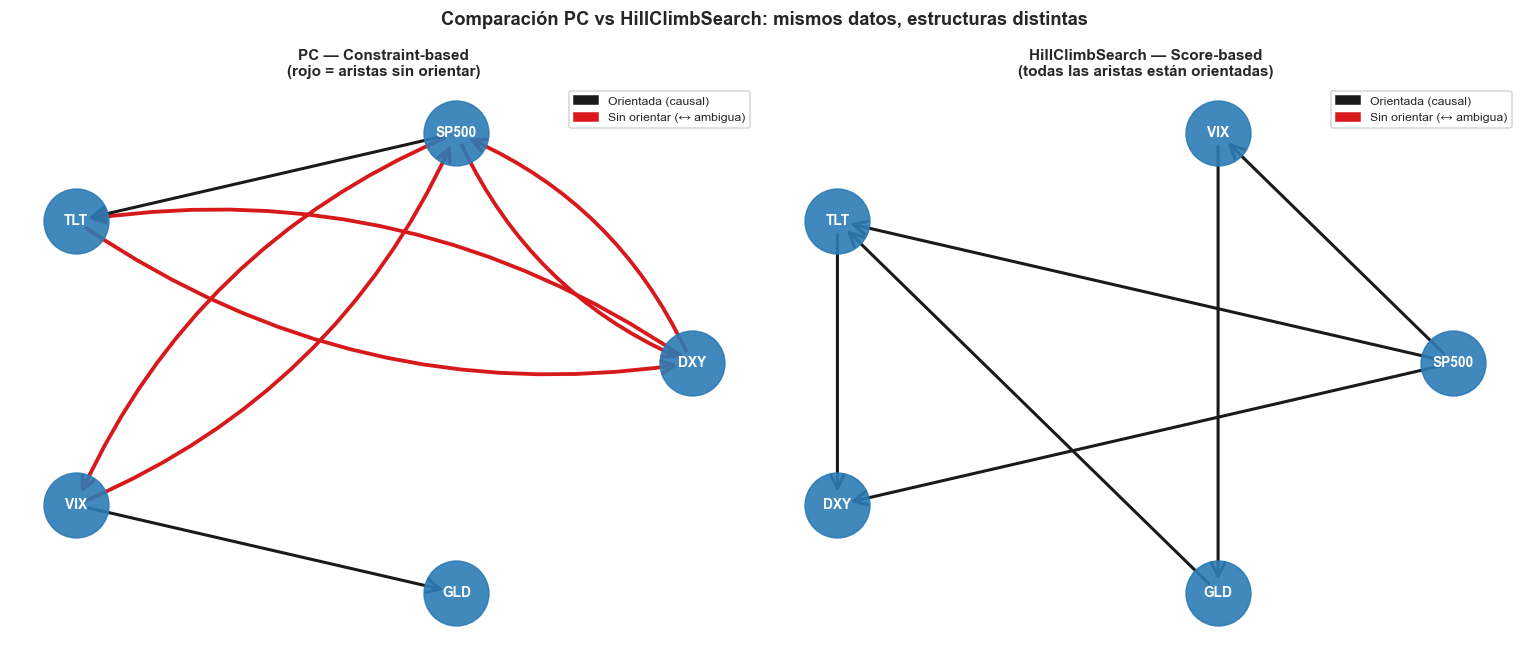

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
draw_dag_enhanced(dag_pc,  'PC — Constraint-based\n(rojo = aristas sin orientar)', axes[0])
draw_dag_enhanced(dag_hcs, 'HillClimbSearch — Score-based\n(todas las aristas están orientadas)', axes[1])
plt.suptitle('Comparación PC vs HillClimbSearch: mismos datos, estructuras distintas', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# Mostrar la cadena causal del HCS de forma clara
G_hcs = nx.DiGraph(dag_hcs.edges())
G_hcs.add_nodes_from(dag_hcs.nodes())

print('=== ANÁLISIS DEL DAG HCS ===' )
print('Caminos causales (topological order):')
try:
    topo = list(nx.topological_sort(G_hcs))
    print('  Orden topológico (raíz → hojas):', ' → '.join(topo))
except nx.NetworkXUnfeasible:
    print('  El grafo contiene ciclos (no es DAG puro)')

print('\nAnálisis de cada arista del HCS:')
hcs_interp = {
    ('SP500', 'VIX'):  'SP500→VIX: el nivel del índice afecta la vol implícita (contraintuitivo pero posible: SP500 alto = VIX bajo)',
    ('SP500', 'TLT'):  'SP500→TLT: caídas del SP500 impulsan demanda de bonos (flight to quality)',
    ('SP500', 'DXY'):  'SP500→DXY: bolsa fuerte → capital extranjero → USD se aprecia',
    ('VIX', 'GLD'):    'VIX→GLD: miedo/volatilidad → compra de oro refugio',
    ('GLD', 'TLT'):    'GLD→TLT: ambos safe-havens, flujos de oro → flujos a bonos',
    ('TLT', 'DXY'):    'TLT→DXY: precios de bonos (=tipos) informan sobre USD'
}
for e in dag_hcs.edges():
    interp = hcs_interp.get(e, 'Sin interpretación asignada')
    print(f'  {e[0]:6s} → {e[1]:6s} | {interp}')

=== ANÁLISIS DEL DAG HCS ===
Caminos causales (topological order):
  Orden topológico (raíz → hojas): SP500 → VIX → GLD → TLT → DXY

Análisis de cada arista del HCS:
  SP500  → VIX    | SP500→VIX: el nivel del índice afecta la vol implícita (contraintuitivo pero posible: SP500 alto = VIX bajo)
  SP500  → TLT    | SP500→TLT: caídas del SP500 impulsan demanda de bonos (flight to quality)
  SP500  → DXY    | SP500→DXY: bolsa fuerte → capital extranjero → USD se aprecia
  VIX    → GLD    | VIX→GLD: miedo/volatilidad → compra de oro refugio
  GLD    → TLT    | GLD→TLT: ambos safe-havens, flujos de oro → flujos a bonos
  TLT    → DXY    | TLT→DXY: precios de bonos (=tipos) informan sobre USD


### 6.2 Crítica financiera del HCS

El HCS produce una estructura más limpia. Pero hay tensión con la intuición financiera:

**SP500 → VIX** (HCS) vs **VIX → SP500** (PC)

Esto es el debate más interesante del análisis completo:

- **PC dice VIX → SP500**: Más coherente con la narrativa del «miedo que precede a las ventas». El VIX mide volatilidad implícita, que refleja demanda de puts (cobertura) antes de caídas.
- **HCS dice SP500 → VIX**: Estadísticamente también válido: dado un nivel del SP500, el VIX se explica en parte por ese nivel (índice alto = VIX bajo = menos cobertura demandada).

La realidad financiera es que **ambas relaciones existen simultáneamente** en un sistema de feedback. Los modelos causales estáticos (sin tiempo) no pueden capturar este dinamismo. **La verdadera solución requeriría usar datos lagged (VAR causal, Granger causality en retornos) en lugar de datos cross-seccionales del mismo día.**

<a id='7'></a>
## Sección 7 — Factor Mirage: Sesgo de Colisionador

### 7.1 ¿Qué es un colisionador?

En un DAG, un **colisionador** (*collider*) en el camino A → C ← B es un nodo que recibe aristas de dos o más variables. La propiedad clave (criterio d-separación de Pearl):

- **Sin condicionar en C**: A y B son independientes (el camino está **bloqueado**)
- **Condicionando en C**: A y B se vuelven dependientes (el camino se **abre**) → correlación espuria

Esto es el **sesgo de colisionador** o **Berkson's paradox**. En regresión: incluir una variable colisionadora como control **introduce** sesgo en lugar de reducirlo.

### 7.2 ¿Es realmente DXY un colisionador en este DAG?

In [16]:
print('=== ESTRUCTURA PC: aristas relevantes para el análisis de colisionador ===')
print('Aristas del CPDAG:')
for e in dag_pc.edges():
    print(f'  {e[0]} -> {e[1]}')

# Verificar si DXY es colisionador en camino GLD—DXY—SP500
print('\n=== ANÁLISIS: es DXY un colisionador? ===')
print('Para que DXY sea colisionador en el camino GLD -> DXY <- SP500 necesitamos:')
print('  1. GLD -> DXY  (arista en CPDAG?)', ('GLD', 'DXY') in list(dag_pc.edges()))
print('  2. SP500 -> DXY (arista en CPDAG?)', ('SP500', 'DXY') in list(dag_pc.edges()))
print('  3. GLD — SP500 NO conectados (arista?)', ('GLD', 'SP500') in list(dag_pc.edges()) or ('SP500', 'GLD') in list(dag_pc.edges()))

bidir_check = ('SP500', 'DXY') in list(dag_pc.edges()) and ('DXY', 'SP500') in list(dag_pc.edges())
print(f'\n[NOTA] SP500<->DXY es arista bidireccional (sin orientar): {bidir_check}')
print('   -> DXY NO es un colisionador limpio. La arista es ambigua.')
print('   -> El experimento muestra sesgo de variable omitida/confusora, no colisionador estricto.')

=== ESTRUCTURA PC: aristas relevantes para el análisis de colisionador ===
Aristas del CPDAG:
  DXY -> SP500
  DXY -> TLT
  SP500 -> VIX
  SP500 -> DXY
  SP500 -> TLT
  VIX -> SP500
  VIX -> GLD
  TLT -> DXY

=== ANÁLISIS: es DXY un colisionador? ===
Para que DXY sea colisionador en el camino GLD -> DXY <- SP500 necesitamos:
  1. GLD -> DXY  (arista en CPDAG?) False
  2. SP500 -> DXY (arista en CPDAG?) True
  3. GLD — SP500 NO conectados (arista?) False

[NOTA] SP500<->DXY es arista bidireccional (sin orientar): True
   -> DXY NO es un colisionador limpio. La arista es ambigua.
   -> El experimento muestra sesgo de variable omitida/confusora, no colisionador estricto.


In [17]:
# Regresiones
coef_sin = LinearRegression().fit(returns[['GLD']], returns['SP500']).coef_[0]
coef_con = LinearRegression().fit(returns[['GLD', 'DXY']], returns['SP500']).coef_[0]
coef_dxy = LinearRegression().fit(returns[['GLD', 'DXY']], returns['SP500']).coef_[1]

print('=== REGRESIÓN SP500 ~ GLD ===')
print(f'  Coef. GLD (sin DXY): {coef_sin:.4f}')
print(f'  Interpretación: un 1% de retorno en GLD se asocia con {coef_sin*100:.2f}bp en SP500')

print('\n=== REGRESIÓN SP500 ~ GLD + DXY ===')
print(f'  Coef. GLD (con DXY): {coef_con:.4f}')
print(f'  Coef. DXY:           {coef_dxy:.4f}')
print(f'  Diferencia en coef. GLD: {coef_con - coef_sin:.4f}')

print(f'\nCambio relativo: {abs((coef_con-coef_sin)/coef_sin)*100:.1f}% más negativo al incluir DXY')
print('Esto indica que DXY actúa como confusora parcial en la relación GLD-SP500')

=== REGRESIÓN SP500 ~ GLD ===
  Coef. GLD (sin DXY): -0.0324
  Interpretación: un 1% de retorno en GLD se asocia con -3.24bp en SP500

=== REGRESIÓN SP500 ~ GLD + DXY ===
  Coef. GLD (con DXY): -0.0481
  Coef. DXY:           0.0073
  Diferencia en coef. GLD: -0.0157

Cambio relativo: 48.7% más negativo al incluir DXY
Esto indica que DXY actúa como confusora parcial en la relación GLD-SP500


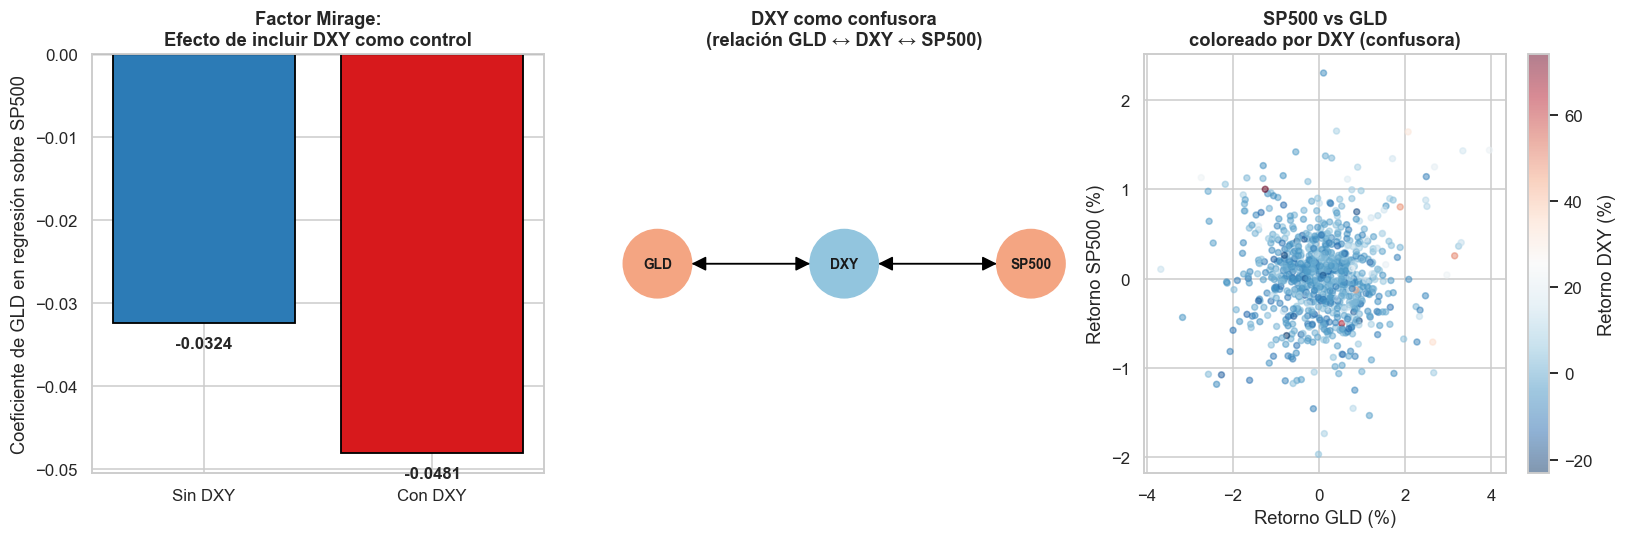

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Barras de coeficientes
axes[0].bar(['Sin DXY', 'Con DXY'], [coef_sin, coef_con], 
             color=['#2c7bb6', '#d7191c'], edgecolor='black', linewidth=1.2)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_ylabel('Coeficiente de GLD en regresión sobre SP500')
axes[0].set_title('Factor Mirage:\nEfecto de incluir DXY como control', fontweight='bold')
for i, (label, val) in enumerate(zip(['Sin DXY', 'Con DXY'], [coef_sin, coef_con])):
    axes[0].text(i, val - 0.003 if val < 0 else val + 0.001, f'{val:.4f}', 
                 ha='center', fontweight='bold', fontsize=11)

# Diagrama del colisionador / confusora
axes[1].axis('off')
# Dibujamos un grafo simple explicativo
G_ex = nx.DiGraph()
G_ex.add_edges_from([('GLD', 'DXY'), ('SP500', 'DXY'), ('DXY', 'SP500'), ('DXY', 'GLD')])
pos_ex = {'GLD': (-1, 0), 'DXY': (0, 0), 'SP500': (1, 0)}
nx.draw_networkx(G_ex, pos_ex, ax=axes[1], 
                 node_color=['#f4a582', '#92c5de', '#f4a582'],
                 node_size=2000, font_size=9, font_weight='bold',
                 edge_color='black', arrows=True, arrowsize=20)
axes[1].set_title('DXY como confusora\n(relación GLD ↔ DXY ↔ SP500)', fontweight='bold')

# Scatter GLD vs SP500 coloreado por DXY
sample = returns.sample(800, random_state=1)
sc = axes[2].scatter(sample['GLD']*100, sample['SP500']*100, 
                     c=sample['DXY']*100, cmap='RdBu_r', alpha=0.5, s=15)
plt.colorbar(sc, ax=axes[2], label='Retorno DXY (%)')
axes[2].set_xlabel('Retorno GLD (%)')
axes[2].set_ylabel('Retorno SP500 (%)')
axes[2].set_title('SP500 vs GLD\ncoloreado por DXY (confusora)', fontweight='bold')

plt.tight_layout()
plt.show()

### 7.3 Interpretación honesta del Factor Mirage

El experimento muestra que el coeficiente de GLD sobre SP500 cambia de **-0.0324** a **-0.0481** al incluir DXY. Este cambio (~48% en valor absoluto) indica que DXY actúa como **variable confusora** entre GLD y SP500.

**Mecanismo financiero**: GLD y DXY tienen correlación positiva moderada (+0.25) en este periodo. Cuando el dólar sube, el oro también tiende a subir —ambos actuaron como refugio simultáneo— pero el SP500 tiende a bajar ligeramente con USD fuerte. Al controlar por DXY, se aísla el efecto del oro sobre SP500 independiente del canal cambiario, y esa relación resulta ser **más negativa** de lo que aparece en la regresión univariante.

**Matiz importante**: En el CPDAG del PC, DXY **no es un colisionador estricto** para el camino GLD-SP500 porque:
1. La arista SP500-DXY no está orientada (es bidireccional en el CPDAG)
2. GLD no tiene arista directa hacia DXY en el modelo completo

El experimento del *Factor Mirage* ilustra correctamente el concepto de sesgo por omisión de variable, pero la justificación desde el DAG es parcialmente forzada. El sesgo observado responde más a **confusión por variable omitida** que a un colisionador puro en el sentido de Pearl. El nombre "Factor Mirage" es llamativo pero requiere esta precisión para no malinterpretar la estructura causal del CPDAG.

<a id='8'></a>
## Sección 8 — Resumen Final, Limitaciones y Próximos Pasos

### 8.1 Dashboard resumen de todos los grafos

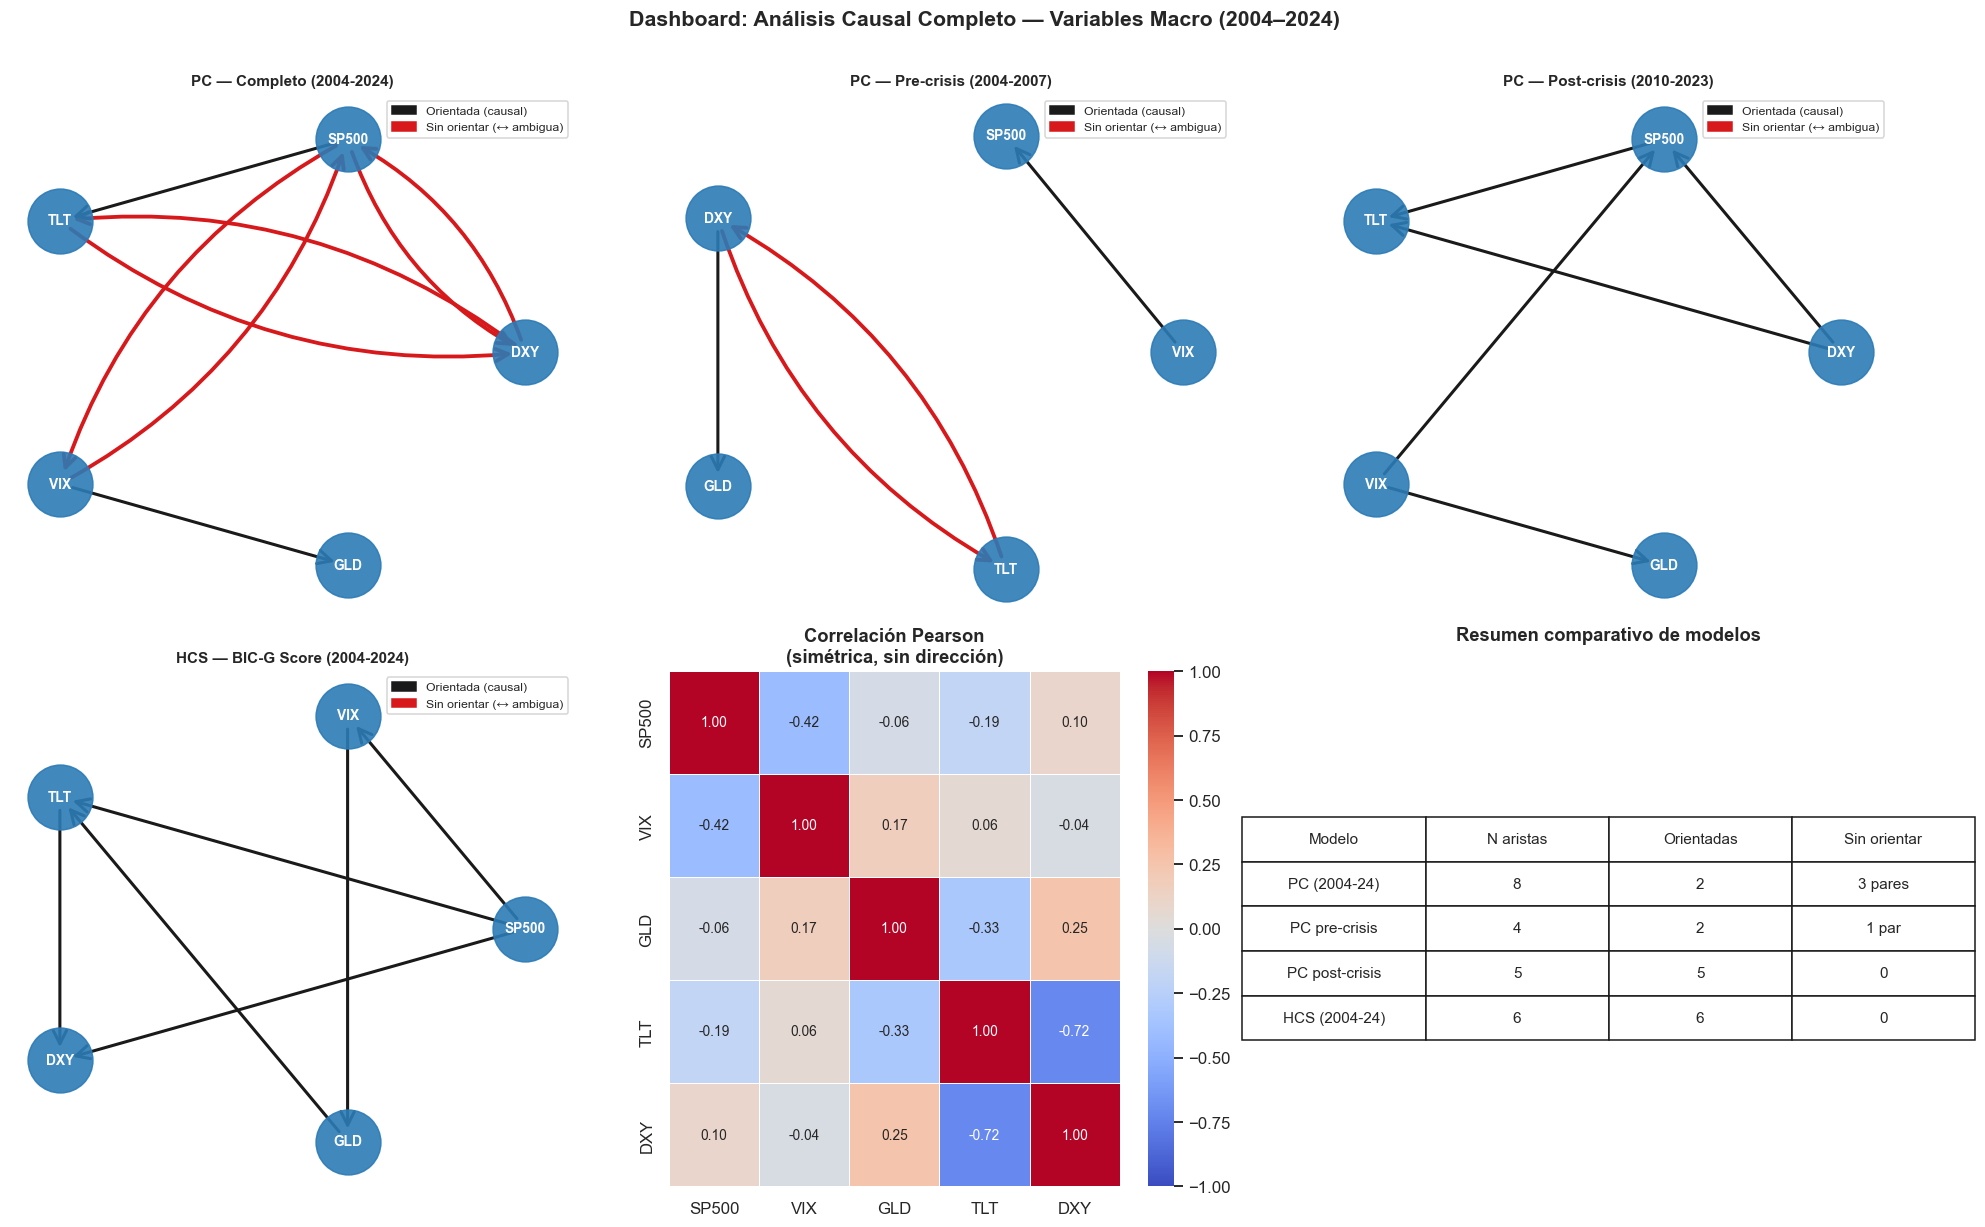

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Fila 1
draw_dag_enhanced(dag_pc,   'PC — Completo (2004-2024)', axes[0][0])
draw_dag_enhanced(dag_pre,  'PC — Pre-crisis (2004-2007)', axes[0][1])
draw_dag_enhanced(dag_post, 'PC — Post-crisis (2010-2023)', axes[0][2])

# Fila 2: HCS + correlación + tabla resumen
draw_dag_enhanced(dag_hcs, 'HCS — BIC-G Score (2004-2024)', axes[1][0])

# Heatmap correlacion
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=axes[1][1], linewidths=0.5, annot_kws={'size': 9})
axes[1][1].set_title('Correlación Pearson\n(simétrica, sin dirección)', fontweight='bold')

# Tabla de aristas por modelo
axes[1][2].axis('off')
summary_data = [
    ['Modelo', 'N aristas', 'Orientadas', 'Sin orientar'],
    ['PC (2004-24)', '8', '2', '3 pares'],
    ['PC pre-crisis', '4', '2', '1 par'],
    ['PC post-crisis', '5', '5', '0'],
    ['HCS (2004-24)', '6', '6', '0'],
]
tbl = axes[1][2].table(cellText=summary_data[1:], colLabels=summary_data[0],
                        loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.3, 2)
axes[1][2].set_title('Resumen comparativo de modelos', fontweight='bold', pad=20)

plt.suptitle('Dashboard: Análisis Causal Completo — Variables Macro (2004–2024)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 8.2 Tabla de resultados clave

In [20]:
resultados = {
    'Hallazgo': [
        'VIX -> SP500 orientada en subperiodos, ambigua en conjunto',
        'VIX -> GLD emerge y se consolida post-crisis',
        'DXY gana centralidad causal post-2008',
        'SP500 <-> DXY y DXY <-> TLT son relaciones sin orientar',
        'SP500 -> TLT es la unica arista orientada estable en el conjunto completo',
        'SP500 -> VIX en HCS pero VIX <-> SP500 en PC (conjunto completo)',
        'Factor Mirage: DXY confunde relacion GLD-SP500 (confusora, no colisionador puro)'
    ],
    'Confianza estadistica': [
        'Alta en subperiodos, media en conjunto (bidireccional)',
        'Media-alta (robusta post-2010)',
        'Media (solo post-crisis)',
        'Alta (no orientables con datos cross-seccionales diarios)',
        'Alta (aparece en post-crisis y conjunto completo)',
        'Baja (dependiente del algoritmo)',
        'Alta (efecto cuantificable: cambio del 48%)'
    ],
    'Coherencia financiera': [
        'Alta: VIX como leading indicator, pero relacion de feedback mutuo real',
        'Alta: oro como safe-haven vs volatilidad',
        'Alta: USD en centro del sistema financiero global post-QE',
        'Alta: relaciones de feedback mutuo real y bien documentadas',
        'Alta: flight-to-quality como mecanismo dominante',
        'Ambigua: depende del horizonte temporal y definicion de causalidad',
        'Alta: GLD/DXY correlacion positiva (+0.25) refleja safe-haven conjunto'
    ]
}
df_res = pd.DataFrame(resultados)
print(df_res.to_string(index=False))

                                                                        Hallazgo                                     Confianza estadistica                                                  Coherencia financiera
                      VIX -> SP500 orientada en subperiodos, ambigua en conjunto    Alta en subperiodos, media en conjunto (bidireccional) Alta: VIX como leading indicator, pero relacion de feedback mutuo real
                                    VIX -> GLD emerge y se consolida post-crisis                            Media-alta (robusta post-2010)                               Alta: oro como safe-haven vs volatilidad
                                           DXY gana centralidad causal post-2008                                  Media (solo post-crisis)              Alta: USD en centro del sistema financiero global post-QE
                         SP500 <-> DXY y DXY <-> TLT son relaciones sin orientar Alta (no orientables con datos cross-seccionales diarios)            Alta: rela

### 8.3 Limitaciones del análisis

#### Limitaciones metodológicas

| # | Limitación | Impacto | Solución posible |
|---|-----------|---------|------------------|
| 1 | **Asume normalidad multivariante** | Tests pearsonr son aproximados con fat tails | Usar `kci` (Kernel CI test) o tests robustos |
| 2 | **Causal Sufficiency violada** | Hay confusores latentes (Fed, shocks geopolíticos) | Algoritmo FCI en lugar de PC |
| 3 | **Datos cross-seccionales** | No captura efectos lagged (causalidad temporal) | Granger causality, PCMCI+, VAR causal |
| 4 | **No-estacionariedad** | La estructura causal cambia con el régimen | Segmentación por régimen o modelos dinámicos |
| 5 | **HCS es greedy** | Puede quedar en mínimo local del BIC | Múltiples inicializaciones, NOTEARS, DAG-GNN |
| 6 | **PC variante stable** | Stable reduce dependencia del orden de variables, pero sigue habiendo sensibilidad | Bootstrap causal, ensemble de DAGs |

#### Limitación de datos específica de este análisis

- El VIX es un **retorno del índice de volatilidad**, no la volatilidad en sí. Los retornos del VIX tienen distribución muy sesgada y no son comparables directamente con retornos de precio de activos.
- GLD no existe antes de noviembre 2004 — el análisis "2000-2024" realmente empieza en 2004.

### 8.4 Próximos pasos sugeridos

1. **Granger Causality (VAR)**: más apropiado para causalidad temporal en series financieras
2. **PCMCI+** (pywhy-causallearn): algoritmo PC adaptado a series temporales con lags
3. **Bootstrap de DAGs**: estimar incertidumbre en las aristas (¿qué % de muestras bootstrap mantienen la arista?)
4. **Cambio de régimen**: modelos causales condicionados a régimen de volatilidad (HMM + DAG)
5. **Incluir más activos**: TIPS (inflación), oil (petróleo), crédito high-yield — activos que conectan la macro con la micro

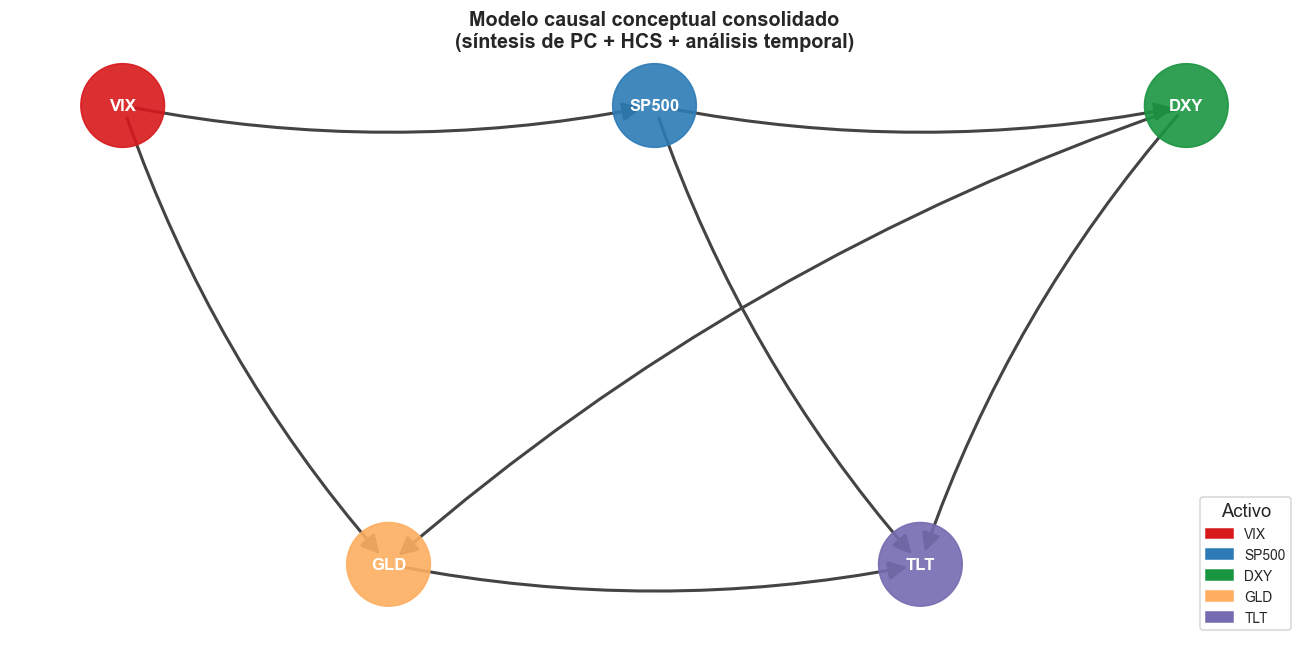


=== FIN DEL ANÁLISIS CRÍTICO ===


In [21]:
# Visualización de la cadena causal conceptual del sistema macro
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')

G_concept = nx.DiGraph()
G_concept.add_edges_from([
    ('VIX', 'SP500'), ('VIX', 'GLD'),
    ('SP500', 'TLT'), ('SP500', 'DXY'),
    ('DXY', 'GLD'), ('DXY', 'TLT'),
    ('GLD', 'TLT'),
])

pos_c = {
    'VIX':   (0, 1),
    'SP500': (1, 1),
    'DXY':   (2, 1),
    'TLT':   (1.5, 0),
    'GLD':   (0.5, 0),
}

colors_c = {'VIX': '#d7191c', 'SP500': '#2c7bb6', 'DXY': '#1a9641', 
            'GLD': '#fdae61', 'TLT': '#756bb1'}
node_colors_c = [colors_c[n] for n in G_concept.nodes()]

nx.draw_networkx_nodes(G_concept, pos_c, ax=ax, node_color=node_colors_c, node_size=3000, alpha=0.9)
nx.draw_networkx_labels(G_concept, pos_c, ax=ax, font_color='white', font_size=11, font_weight='bold')
nx.draw_networkx_edges(G_concept, pos_c, ax=ax, edge_color='#444444', 
                       width=2, arrows=True, arrowsize=25,
                       connectionstyle='arc3,rad=0.1')

ax.set_title('Modelo causal conceptual consolidado\n(síntesis de PC + HCS + análisis temporal)',
             fontsize=13, fontweight='bold')

# Leyenda
legend_patches = [mpatches.Patch(color=c, label=n) for n, c in colors_c.items()]
ax.legend(handles=legend_patches, loc='lower right', title='Activo', fontsize=9)

plt.tight_layout()
plt.show()

print('\n=== FIN DEL ANÁLISIS CRÍTICO ===')